In [1]:
import matplotlib.pyplot as plt 
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split

In [2]:
df = load_diabetes(as_frame=True).frame

In [3]:
df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [6]:
X = df.drop("target", axis=1)
y = df["target"]

In [7]:
X.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


In [8]:
# train test split 

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [9]:
from sklearn.tree import DecisionTreeRegressor

model = DecisionTreeRegressor()
model.fit(X_train, y_train)

DecisionTreeRegressor()

In [10]:
from sklearn.metrics import r2_score, mean_squared_error

y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

print("MSE train :",  mean_squared_error(y_train, y_pred_train))
print("MSE test :",  mean_squared_error(y_test, y_pred_test))

print("r2 train :",  r2_score(y_train, y_pred_train))
print("r2 test :",  r2_score(y_test, y_pred_test))

MSE train : 0.0
MSE test : 4906.966292134832
r2 train : 1.0
r2 test : 0.07383432467582596


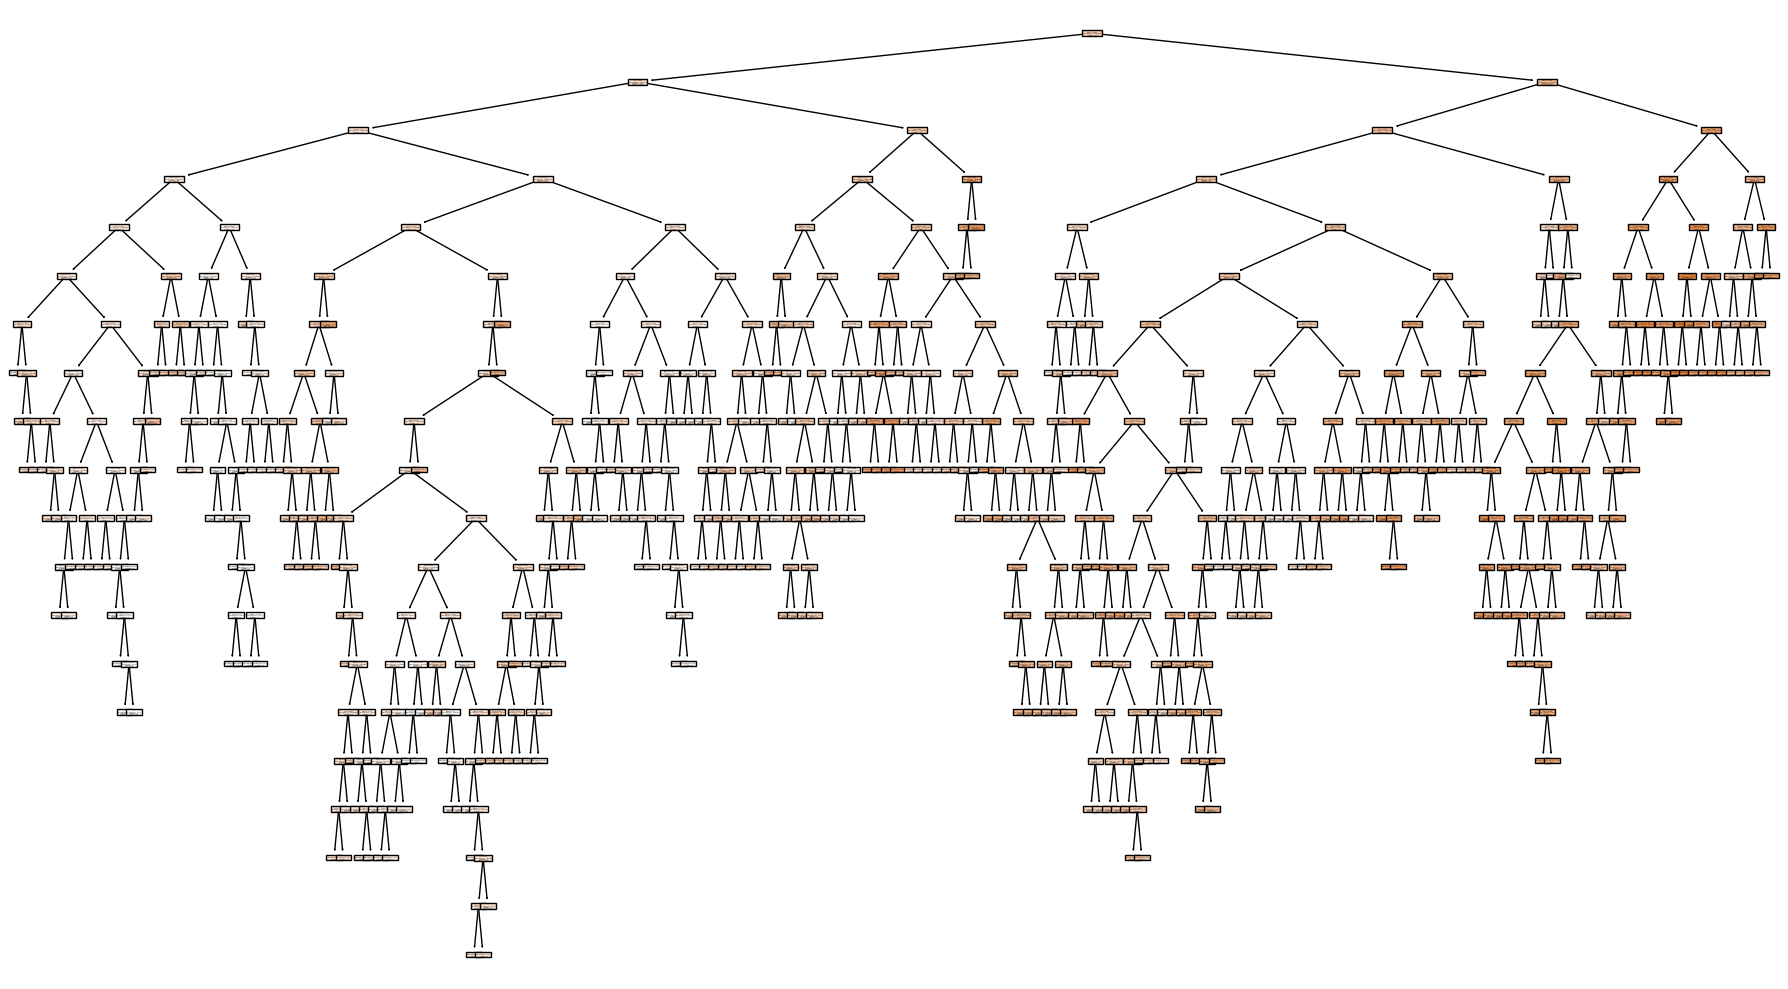

In [14]:
from sklearn.tree import plot_tree

plt.figure(figsize=(18, 10))

plot_tree(
    model,
    feature_names=X.columns,
    filled=True
)

plt.tight_layout()

In [16]:
# pre-pruning and post-pruning

from sklearn.tree import DecisionTreeRegressor

model = DecisionTreeRegressor(max_depth=7, min_samples_split=20)
model.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=7, min_samples_split=20)

In [17]:
from sklearn.metrics import r2_score, mean_squared_error

y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

print("MSE train :",  mean_squared_error(y_train, y_pred_train))
print("MSE test :",  mean_squared_error(y_test, y_pred_test))

print("r2 train :",  r2_score(y_train, y_pred_train))
print("r2 test :",  r2_score(y_test, y_pred_test))

MSE train : 1642.6796074536235
MSE test : 3611.043504256895
r2 train : 0.7296622762459943
r2 test : 0.31843335644964677


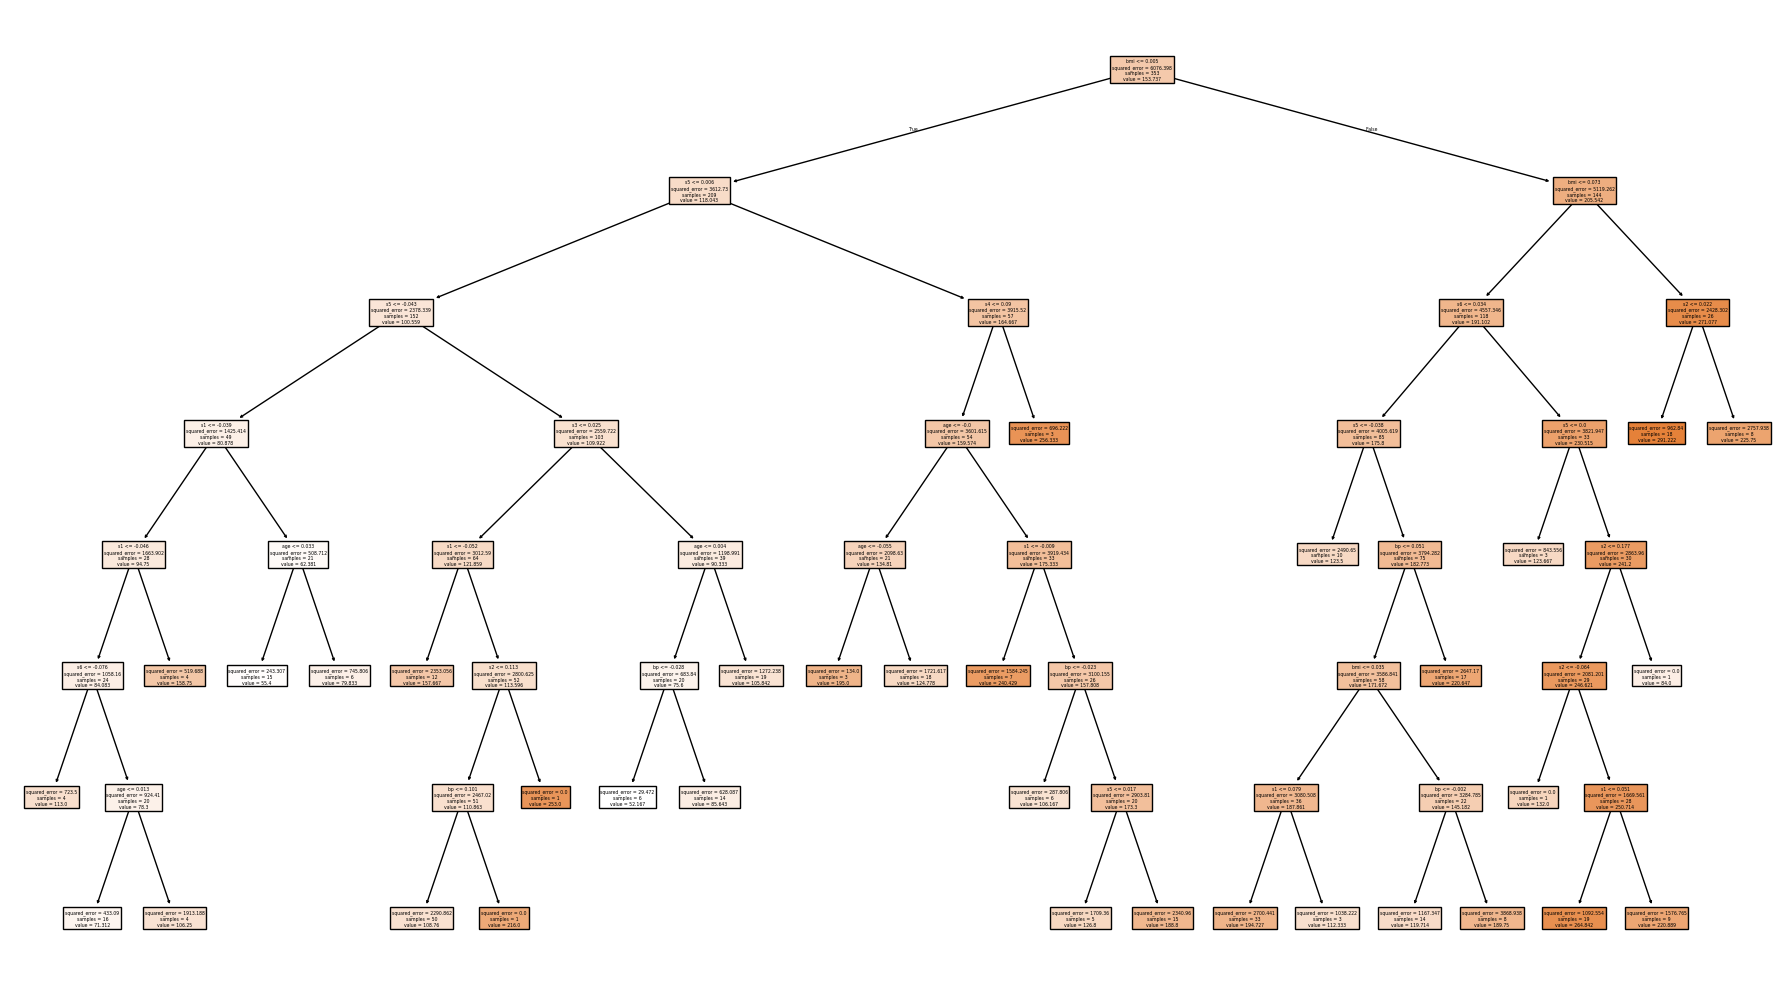

In [18]:
plt.figure(figsize=(18, 10))

plot_tree(
    model,
    feature_names=X.columns,
    filled=True
)

plt.tight_layout()